# 02 — Eksploracyjna analiza danych

Wczytuje splity z `data/processed/` (z `01_data_preparation.ipynb`) i zapisuje figury.
Analiza obejmuje 8 emocji Plutchika; sentyment wykluczony z modelowania.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# font_scale >1: figury są zmniejszane przy osadzaniu, więc czcionki
# must be oversized here to stay readable in print
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.4)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 12

PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

EMOTIONS = ["radość", "smutek", "zaufanie", "wstręt", "strach", "gniew", "przeczuwanie", "zdziwienie"]
SENTIMENTS = ["pozytywny", "negatywny", "neutralny", "ambiwalentny", "sarkazm"]  # EDA reference only, excluded from modeling
TARGET_LABELS = EMOTIONS

# --- Load prepared data ---
tw_train = pd.read_csv(PROCESSED_DIR / "twitteremo_train.csv")
tw_val   = pd.read_csv(PROCESSED_DIR / "twitteremo_val.csv")
tw_test  = pd.read_csv(PROCESSED_DIR / "twitteremo_test.csv")
tw_all   = pd.concat([tw_train, tw_val, tw_test], ignore_index=True)

go_train = pd.read_csv(PROCESSED_DIR / "go_emotions_train.csv")
go_val   = pd.read_csv(PROCESSED_DIR / "go_emotions_val.csv")
go_test  = pd.read_csv(PROCESSED_DIR / "go_emotions_test.csv")
go_all   = pd.concat([go_train, go_val, go_test], ignore_index=True)

ce_train = pd.read_csv(PROCESSED_DIR / "clarin_emo_train.csv")
ce_val   = pd.read_csv(PROCESSED_DIR / "clarin_emo_val.csv")
ce_test  = pd.read_csv(PROCESSED_DIR / "clarin_emo_test.csv")
ce_all   = pd.concat([ce_train, ce_val, ce_test], ignore_index=True)

print(f"TwitterEmo:   {len(tw_all):,} total ({len(tw_train):,} train / {len(tw_val):,} val / {len(tw_test):,} test)")
print(f"GoEmotions PL: {len(go_all):,} total ({len(go_train):,} train / {len(go_val):,} val / {len(go_test):,} test)")
print(f"CLARIN-Emo:   {len(ce_all):,} total ({len(ce_train):,} train / {len(ce_val):,} val / {len(ce_test):,} test)")
print(f"Target labels ({len(TARGET_LABELS)}): {TARGET_LABELS}")

TwitterEmo:   35,856 total (28,684 train / 5,737 val / 1,435 test)
GoEmotions PL: 42,845 total (34,276 train / 6,855 val / 1,714 test)
CLARIN-Emo:   8,856 total (6,367 train / 1,233 val / 1,256 test)
Target labels (8): ['radość', 'smutek', 'zaufanie', 'wstręt', 'strach', 'gniew', 'przeczuwanie', 'zdziwienie']


---
## 1. Emotion Distribution

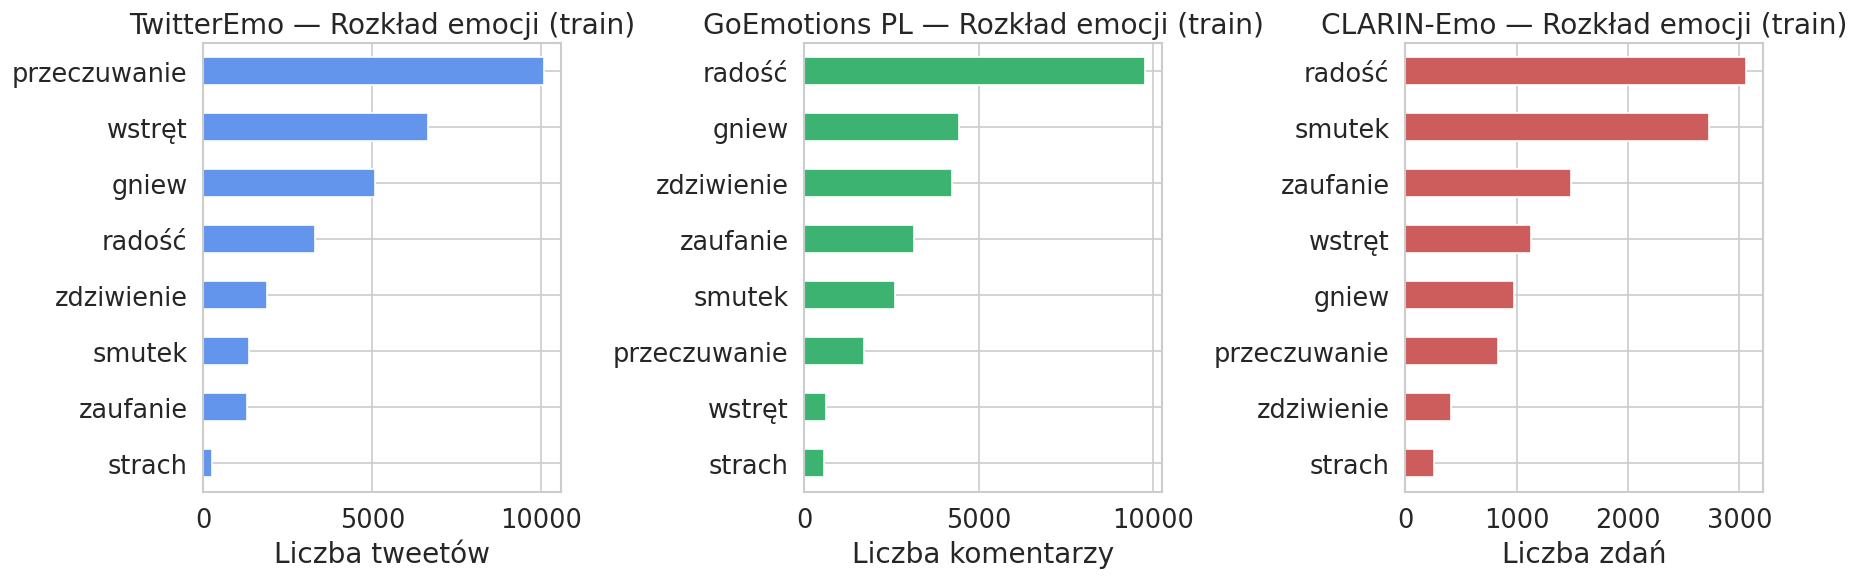

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

tw_train[EMOTIONS].sum().sort_values().plot(kind="barh", ax=axes[0], color="cornflowerblue")
axes[0].set_title("TwitterEmo — Rozkład emocji (train)")
axes[0].set_xlabel("Liczba tweetów")

go_train[EMOTIONS].sum().sort_values().plot(kind="barh", ax=axes[1], color="mediumseagreen")
axes[1].set_title("GoEmotions PL — Rozkład emocji (train)")
axes[1].set_xlabel("Liczba komentarzy")

ce_train[EMOTIONS].sum().sort_values().plot(kind="barh", ax=axes[2], color="indianred")
axes[2].set_title("CLARIN-Emo — Rozkład emocji (train)")
axes[2].set_xlabel("Liczba zdań")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_emotion_distribution.pdf", bbox_inches="tight")
plt.show()

---
## 3. Niezbalansowanie klas

Wskaźnik = liczność najczęstszej / najrzadszej.

In [3]:
def imbalance_report(df: pd.DataFrame, labels: list[str], name: str) -> pd.DataFrame:
    """Compute per-label positive rate and imbalance metrics."""
    counts = df[labels].sum()
    total = len(df)
    report = pd.DataFrame({
        "count": counts,
        "% positive": (counts / total * 100).round(1),
        "% negative": ((total - counts) / total * 100).round(1),
        "pos:neg ratio": (counts / (total - counts)).round(3),
    })
    report = report.sort_values("count", ascending=False)
    
    imbalance_ratio = counts.max() / counts[counts > 0].min()
    print(f"\n{name}:")
    print(f"  Most frequent:  {counts.idxmax()} ({counts.max()})")
    print(f"  Least frequent: {counts[counts > 0].idxmin()} ({counts[counts > 0].min()})")
    print(f"  Imbalance ratio: {imbalance_ratio:.1f}x")
    return report

print("=== EMOTIONS ===")
tw_imb = imbalance_report(tw_train, EMOTIONS, "TwitterEmo")
display(tw_imb)

go_imb = imbalance_report(go_train, EMOTIONS, "GoEmotions PL")
display(go_imb)

ce_imb = imbalance_report(ce_train, EMOTIONS, "CLARIN-Emo")
display(ce_imb)

=== EMOTIONS ===

TwitterEmo:
  Most frequent:  przeczuwanie (10069)
  Least frequent: strach (258)
  Imbalance ratio: 39.0x


,count,% positive,% negative,pos:neg ratio
przeczuwanie,10069,35.1,64.9,0.541
wstręt,6655,23.2,76.8,0.302
gniew,5065,17.7,82.3,0.214
radość,3290,11.5,88.5,0.130
zdziwienie,1868,6.5,93.5,0.070
smutek,1335,4.7,95.3,0.049
zaufanie,1289,4.5,95.5,0.047
strach,258,0.9,99.1,0.009



GoEmotions PL:
  Most frequent:  radość (9770)
  Least frequent: strach (574)
  Imbalance ratio: 17.0x


,count,% positive,% negative,pos:neg ratio
radość,9770,28.5,71.5,0.399
gniew,4430,12.9,87.1,0.148
zdziwienie,4244,12.4,87.6,0.141
zaufanie,3135,9.1,90.9,0.101
smutek,2598,7.6,92.4,0.082
przeczuwanie,1718,5.0,95.0,0.053
wstręt,630,1.8,98.2,0.019
strach,574,1.7,98.3,0.017



CLARIN-Emo:
  Most frequent:  radość (3056)
  Least frequent: strach (256)
  Imbalance ratio: 11.9x


,count,% positive,% negative,pos:neg ratio
radość,3056,48.0,52.0,0.923
smutek,2724,42.8,57.2,0.748
zaufanie,1488,23.4,76.6,0.305
wstręt,1126,17.7,82.3,0.215
gniew,975,15.3,84.7,0.181
przeczuwanie,828,13.0,87.0,0.149
zdziwienie,413,6.5,93.5,0.069
strach,256,4.0,96.0,0.042


---
## 4. Korelacja emocji

Które emocje współwystępują — przesłanka do wyboru strategii multi-label.

In [ ]:
# Układ 2+1: dwa zbiory u góry, CLARIN-Emo pod spodem.
# — notatnik ją wywołuje, żeby kod rysujący istniał w jednym miejscu.
import sys
sys.path.insert(0, str(Path("..") / "tools"))
from gen_eda_figures import correlation_figure

fig = correlation_figure()
fig.savefig(FIGURES_DIR / "eda_emotion_correlation.pdf", bbox_inches="tight")
plt.show()


# Strongest correlations
for _name, _corr in [("TwitterEmo", corr_tw), ("GoEmotions PL", corr_go), ("CLARIN-Emo", corr_ce)]:
    print(f"\n{_name} — Najsilniejsze korelacje:")
    corr_pairs = _corr.unstack().drop_duplicates()
    corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
    print(corr_pairs.reindex(corr_pairs.abs().nlargest(6).index).to_string())

---
## 5. Długość tekstów

Rozkład liczby słów — dobór `max_length` dla transformerów.

In [ ]:
# Układ 2+1: dwa zbiory u góry, CLARIN-Emo pod spodem.
# — notatnik ją wywołuje, żeby kod rysujący istniał w jednym miejscu.
import sys
sys.path.insert(0, str(Path("..") / "tools"))
from gen_eda_figures import length_figure

fig = length_figure()
fig.savefig(FIGURES_DIR / "eda_text_length.pdf", bbox_inches="tight")
plt.show()


# Statistics
stats = pd.DataFrame({
    "TwitterEmo": tw_all["word_count"].describe(),
    "GoEmotions PL": go_all["word_count"].describe(),
    "CLARIN-Emo": ce_all["word_count"].describe(),
}).round(1)
display(stats)

---
## 6. Porównanie zbiorów

Proporcje emocji obok siebie.

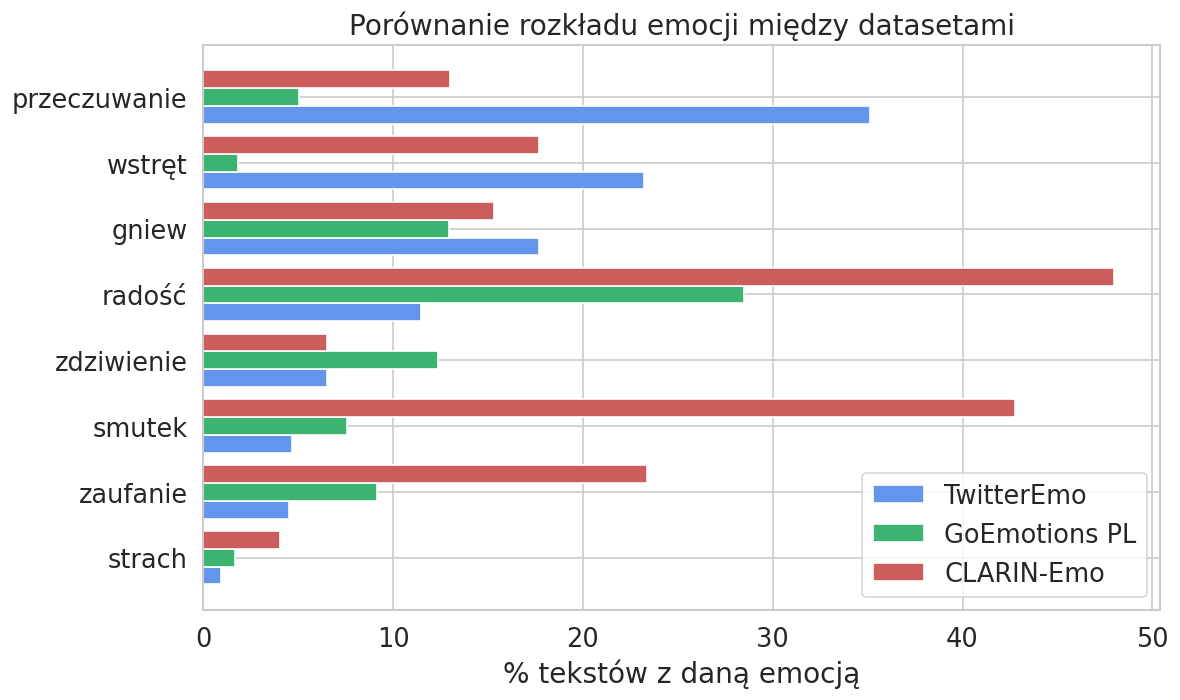

,TwitterEmo (%),GoEmotions PL (%),CLARIN-Emo (%)
strach,0.9,1.7,4.0
zaufanie,4.5,9.1,23.4
smutek,4.7,7.6,42.8
zdziwienie,6.5,12.4,6.5
radość,11.5,28.5,48.0
gniew,17.7,12.9,15.3
wstręt,23.2,1.8,17.7
przeczuwanie,35.1,5.0,13.0


In [6]:
# Proportional comparison (normalize by dataset size)
tw_pct = (tw_train[EMOTIONS].sum() / len(tw_train) * 100)
go_pct = (go_train[EMOTIONS].sum() / len(go_train) * 100)
ce_pct = (ce_train[EMOTIONS].sum() / len(ce_train) * 100)

comparison = pd.DataFrame({
    "TwitterEmo (%)": tw_pct,
    "GoEmotions PL (%)": go_pct,
    "CLARIN-Emo (%)": ce_pct,
}).sort_values("TwitterEmo (%)", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison))
width = 0.27

ax.barh(x - width, comparison["TwitterEmo (%)"], width, label="TwitterEmo", color="cornflowerblue")
ax.barh(x, comparison["GoEmotions PL (%)"], width, label="GoEmotions PL", color="mediumseagreen")
ax.barh(x + width, comparison["CLARIN-Emo (%)"], width, label="CLARIN-Emo", color="indianred")
ax.set_yticks(x)
ax.set_yticklabels(comparison.index)
ax.set_xlabel("% tekstów z daną emocją")
ax.set_title("Porównanie rozkładu emocji między datasetami")
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_dataset_comparison.pdf", bbox_inches="tight")
plt.show()

display(comparison.round(1))

---
## 7. Statystyki multi-label

Kardynalność etykiet na tekst.

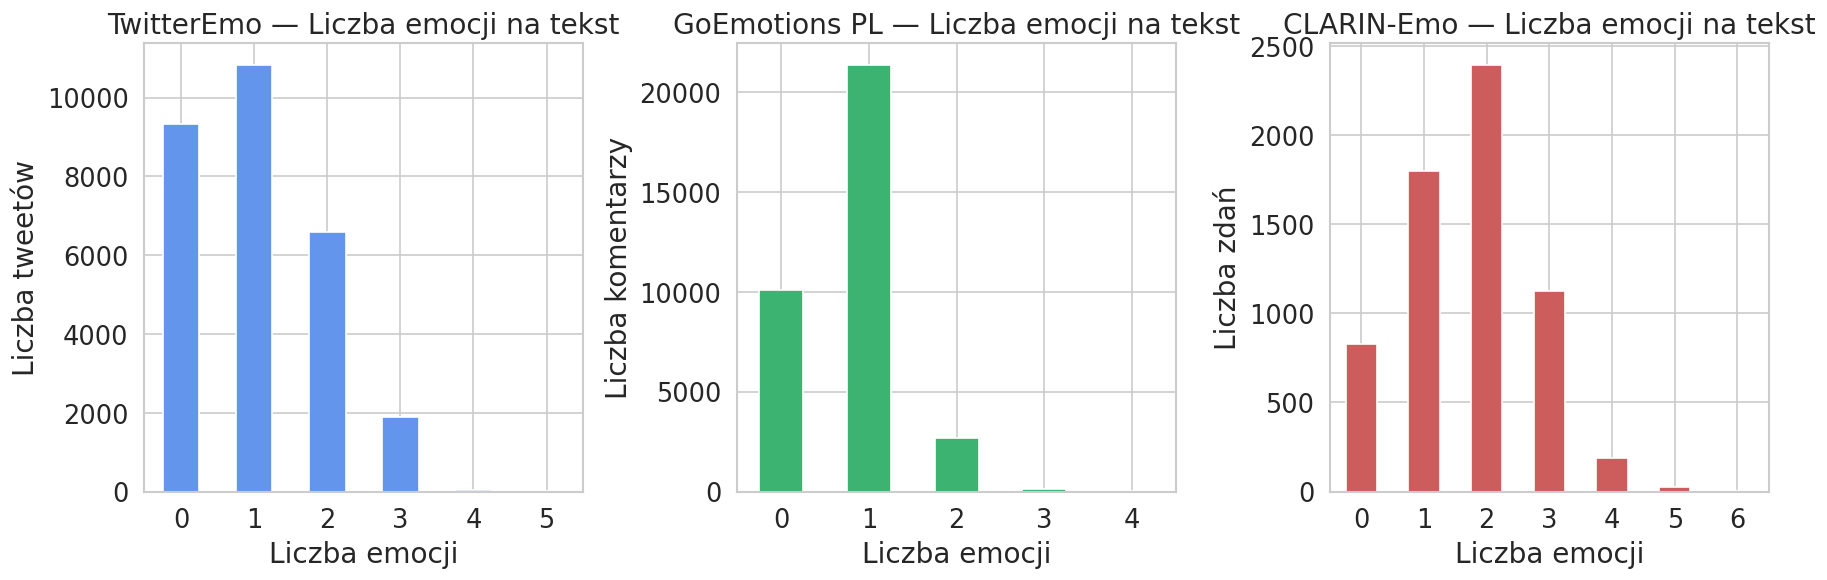

TwitterEmo — średnia liczba emocji/tekst: 1.04
GoEmotions PL — średnia liczba emocji/tekst: 0.79
CLARIN-Emo — średnia liczba emocji/tekst: 1.71

TwitterEmo — teksty bez żadnej emocji: 9328
GoEmotions PL — teksty bez żadnej emocji: 10095
CLARIN-Emo — teksty bez żadnej emocji: 829


In [7]:
# Label cardinality (emotions only — sentiments are derived)
tw_train["n_emotions"] = tw_train[EMOTIONS].sum(axis=1)
go_train["n_emotions"] = go_train[EMOTIONS].sum(axis=1)
ce_train["n_emotions"] = ce_train[EMOTIONS].sum(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

tw_train["n_emotions"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="cornflowerblue")
axes[0].set_title("TwitterEmo — Liczba emocji na tekst")
axes[0].set_xlabel("Liczba emocji")
axes[0].set_ylabel("Liczba tweetów")
axes[0].tick_params(axis="x", rotation=0)

go_train["n_emotions"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="mediumseagreen")
axes[1].set_title("GoEmotions PL — Liczba emocji na tekst")
axes[1].set_xlabel("Liczba emocji")
axes[1].set_ylabel("Liczba komentarzy")
axes[1].tick_params(axis="x", rotation=0)

ce_train["n_emotions"].value_counts().sort_index().plot(kind="bar", ax=axes[2], color="indianred")
axes[2].set_title("CLARIN-Emo — Liczba emocji na tekst")
axes[2].set_xlabel("Liczba emocji")
axes[2].set_ylabel("Liczba zdań")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_label_cardinality.pdf", bbox_inches="tight")
plt.show()

print(f"TwitterEmo — średnia liczba emocji/tekst: {tw_train['n_emotions'].mean():.2f}")
print(f"GoEmotions PL — średnia liczba emocji/tekst: {go_train['n_emotions'].mean():.2f}")
print(f"CLARIN-Emo — średnia liczba emocji/tekst: {ce_train['n_emotions'].mean():.2f}")
print(f"\nTwitterEmo — teksty bez żadnej emocji: {(tw_train['n_emotions'] == 0).sum()}")
print(f"GoEmotions PL — teksty bez żadnej emocji: {(go_train['n_emotions'] == 0).sum()}")
print(f"CLARIN-Emo — teksty bez żadnej emocji: {(ce_train['n_emotions'] == 0).sum()}")

---
## 8. Najczęstsze kombinacje emocji

In [8]:
def top_label_combos(df: pd.DataFrame, labels: list[str], n: int = 15) -> pd.DataFrame:
    """Find most common label combinations."""
    combos = df[labels].apply(
        lambda row: frozenset(l for l, v in zip(labels, row) if v == 1), axis=1
    )
    counts = combos.value_counts().head(n)
    result = pd.DataFrame({
        "combination": [", ".join(sorted(c)) if c else "(brak emocji)" for c in counts.index],
        "count": counts.values,
        "% total": (counts.values / len(df) * 100).round(1),
    })
    return result

print("=== TwitterEmo — Top 15 kombinacji emocji ===")
display(top_label_combos(tw_train, EMOTIONS))

print("\n=== GoEmotions PL — Top 15 kombinacji emocji ===")
display(top_label_combos(go_train, EMOTIONS))

=== TwitterEmo — Top 15 kombinacji emocji ===


,combination,count,% total
0,(brak emocji),9328,32.5
1,przeczuwanie,4716,16.4
2,radość,2085,7.3
3,"gniew, wstręt",1596,5.6
4,"przeczuwanie, wstręt",1583,5.5
5,wstręt,1465,5.1
6,"gniew, przeczuwanie, wstręt",1260,4.4
7,zdziwienie,851,3.0
8,gniew,754,2.6
9,"gniew, przeczuwanie",711,2.5



=== GoEmotions PL — Top 15 kombinacji emocji ===


,combination,count,% total
0,(brak emocji),10095,29.5
1,radość,8283,24.2
2,gniew,3659,10.7
3,zdziwienie,3292,9.6
4,zaufanie,2233,6.5
5,smutek,1962,5.7
6,przeczuwanie,1073,3.1
7,strach,455,1.3
8,"radość, zaufanie",425,1.2
9,wstręt,423,1.2


---
## 9. Etapy preprocessingu

Wpływ każdego etapu na rozmiar słownika i długość tekstów: surowy → czyszczony → lemmatyzacja + stopwords.

=== TwitterEmo ===


,wszystkie tokeny,unikalny słownik,śr. tokenów/tekst,mediana tokenów,% pustych tekstów
etap,,,,,
surowy,544587,123955,19.0,15.0,0.0
czyszczony (URL/@/#/cyfry),504237,120865,17.6,14.0,0.0
lemmatyzacja + stopwords,303867,51381,10.6,9.0,0.0



=== GoEmotions PL ===


,wszystkie tokeny,unikalny słownik,śr. tokenów/tekst,mediana tokenów,% pustych tekstów
etap,,,,,
surowy,372490,70647,10.9,10.0,0.0
czyszczony (URL/@/#/cyfry),370703,69737,10.8,10.0,0.0
lemmatyzacja + stopwords,208706,26222,6.1,6.0,0.0



=== CLARIN-Emo ===


,wszystkie tokeny,unikalny słownik,śr. tokenów/tekst,mediana tokenów,% pustych tekstów
etap,,,,,
surowy,112382,34096,17.7,14.0,0.0
czyszczony (URL/@/#/cyfry),110734,33124,17.4,14.0,0.0
lemmatyzacja + stopwords,70553,15036,11.1,9.0,0.0


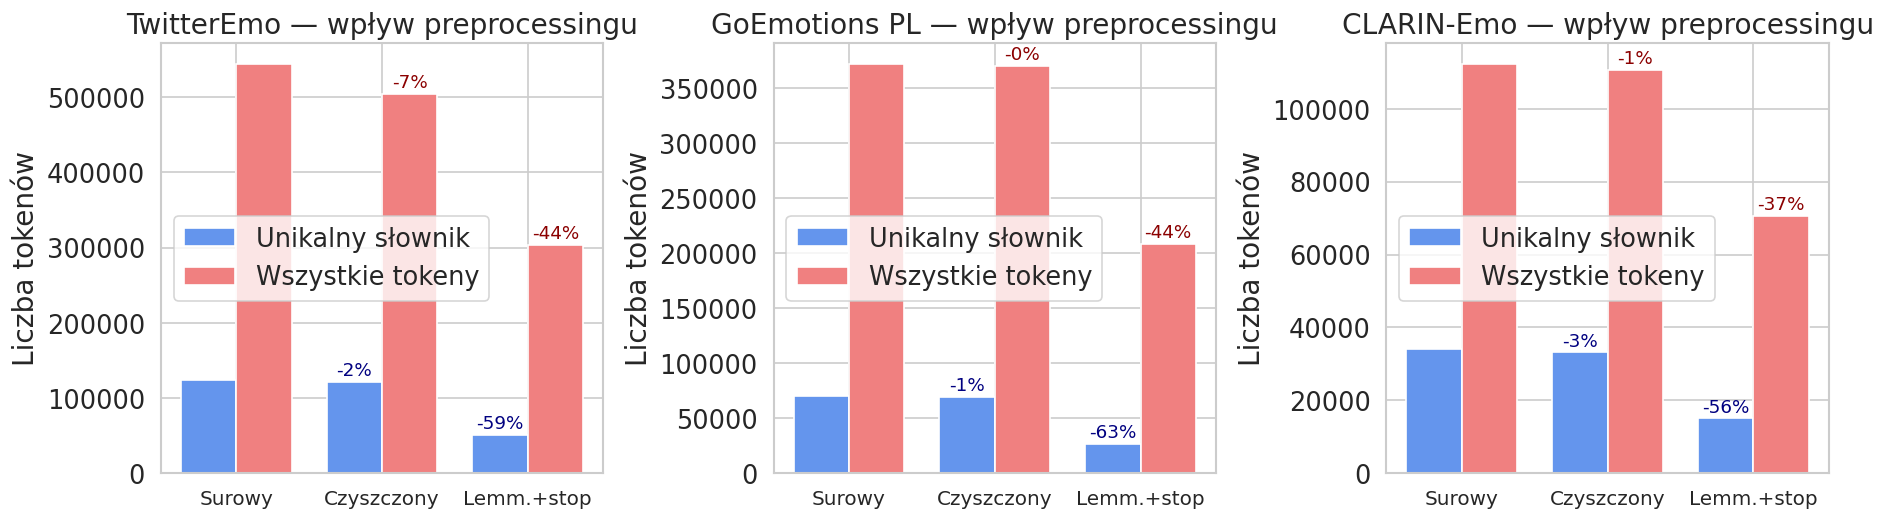

In [9]:
import re as _re

def _clean_only(text: str) -> str:
    """URL/@/#/digits removal without lemmatization — intermediate preprocessing stage."""
    if not isinstance(text, str):
        return ""
    text = _re.sub(r"http\S+", "", text)
    text = _re.sub(r"@\w+", "", text)
    text = _re.sub(r"#", "", text)
    text = _re.sub(r"\d+", "", text)
    return text.strip()

def _vocab_stats(texts: pd.Series, stage: str) -> dict:
    texts = texts.dropna().loc[texts.str.strip() != ""]
    token_lists = texts.str.split()
    all_tokens = [t for tl in token_lists if isinstance(tl, list) for t in tl]
    return {
        "etap": stage,
        "wszystkie tokeny": len(all_tokens),
        "unikalny słownik": len(set(all_tokens)),
        "śr. tokenów/tekst": round(token_lists.apply(lambda x: len(x) if isinstance(x, list) else 0).mean(), 1),
        "mediana tokenów": token_lists.apply(lambda x: len(x) if isinstance(x, list) else 0).median(),
        "% pustych tekstów": round((texts.str.strip() == "").mean() * 100, 2),
    }

print("=== TwitterEmo ===")
tw_stage1 = tw_train["tekst"].apply(_clean_only)
stats_tw_raw = _vocab_stats(tw_train["tekst"], "surowy")
stats_tw_mid = _vocab_stats(tw_stage1, "czyszczony (URL/@/#/cyfry)")
stats_tw_lem = _vocab_stats(tw_train["clean_text"], "lemmatyzacja + stopwords")
tw_prep_df = pd.DataFrame([stats_tw_raw, stats_tw_mid, stats_tw_lem]).set_index("etap")
display(tw_prep_df)

print("\n=== GoEmotions PL ===")
go_stage1 = go_train["text_pl"].apply(_clean_only)
stats_go_raw = _vocab_stats(go_train["text_pl"], "surowy")
stats_go_mid = _vocab_stats(go_stage1, "czyszczony (URL/@/#/cyfry)")
stats_go_lem = _vocab_stats(go_train["clean_text"], "lemmatyzacja + stopwords")
go_prep_df = pd.DataFrame([stats_go_raw, stats_go_mid, stats_go_lem]).set_index("etap")
display(go_prep_df)

print("\n=== CLARIN-Emo ===")
ce_stage1 = ce_train["tekst"].apply(_clean_only)
stats_ce_raw = _vocab_stats(ce_train["tekst"], "surowy")
stats_ce_mid = _vocab_stats(ce_stage1, "czyszczony (URL/@/#/cyfry)")
stats_ce_lem = _vocab_stats(ce_train["clean_text"], "lemmatyzacja + stopwords")
ce_prep_df = pd.DataFrame([stats_ce_raw, stats_ce_mid, stats_ce_lem]).set_index("etap")
display(ce_prep_df)

# Visualization — vocabulary and token count reduction across stages
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.5))
stages = ["surowy", "czyszczony", "lemmatyzacja+stopwords"]

for ax, (ds_name, stats_list) in zip(axes, [
    ("TwitterEmo", [stats_tw_raw, stats_tw_mid, stats_tw_lem]),
    ("GoEmotions PL", [stats_go_raw, stats_go_mid, stats_go_lem]),
    ("CLARIN-Emo", [stats_ce_raw, stats_ce_mid, stats_ce_lem]),
]):
    vocab_sizes = [s["unikalny słownik"] for s in stats_list]
    token_counts = [s["wszystkie tokeny"] for s in stats_list]
    x = np.arange(3)
    w = 0.38
    bars_v = ax.bar(x - w / 2, vocab_sizes, w, label="Unikalny słownik", color="cornflowerblue")
    bars_t = ax.bar(x + w / 2, token_counts, w, label="Wszystkie tokeny", color="lightcoral")
    ax.set_xticks(x)
    ax.set_xticklabels(["Surowy", "Czyszczony", "Lemm.+stop"], fontsize=12)
    ax.set_ylabel("Liczba tokenów")
    ax.set_title(f"{ds_name} — wpływ preprocessingu")
    ax.legend()
    for i, (v, t) in enumerate(zip(vocab_sizes, token_counts)):
        if i > 0:
            v_red = (1 - v / vocab_sizes[0]) * 100
            t_red = (1 - t / token_counts[0]) * 100
            ax.annotate(f"-{v_red:.0f}%", xy=(x[i] - w / 2, v), xytext=(0, 4),
                        textcoords="offset points", ha="center", fontsize=11, color="navy")
            ax.annotate(f"-{t_red:.0f}%", xy=(x[i] + w / 2, t), xytext=(0, 4),
                        textcoords="offset points", ha="center", fontsize=11, color="darkred")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_preprocessing_comparison.pdf", bbox_inches="tight")
plt.show()

---
## 10. Słownictwo dyskryminujące per emocja (TF-IDF)

Różnica średnich TF-IDF między próbkami z daną emocją a bez niej.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer as _TFV

def top_discriminative_terms(
    df: pd.DataFrame,
    label: str,
    text_col: str = "clean_text",
    top_n: int = 8,
    max_features: int = 20_000,
) -> pd.Series:
    """TF-IDF mean difference between positive and negative class for a binary label."""
    pos = df[df[label] == 1][text_col].fillna("").tolist()
    neg = df[df[label] == 0][text_col].fillna("").tolist()
    if len(pos) < 5:
        return pd.Series(dtype=float)
    vec = _TFV(max_features=max_features, sublinear_tf=True, min_df=3)
    X = vec.fit_transform(pos + neg)
    n = len(pos)
    pos_mean = np.asarray(X[:n].mean(axis=0)).flatten()
    neg_mean = np.asarray(X[n:].mean(axis=0)).flatten()
    diff = pos_mean - neg_mean
    terms = vec.get_feature_names_out()
    idx = np.argsort(diff)[-top_n:][::-1]
    return pd.Series(diff[idx], index=terms[idx])

fig, axes = plt.subplots(len(EMOTIONS), 3, figsize=(13, 19))

for row_i, emo in enumerate(EMOTIONS):
    for col_i, (ds_name, df, color) in enumerate([
        ("TwitterEmo", tw_train, "cornflowerblue"),
        ("GoEmotions PL", go_train, "mediumseagreen"),
        ("CLARIN-Emo", ce_train, "indianred"),
    ]):
        ax = axes[row_i, col_i]
        terms = top_discriminative_terms(df, emo)
        if terms.empty:
            ax.set_visible(False)
            continue
        terms.sort_values().plot(kind="barh", ax=ax, color=color)
        ax.set_title(f"{emo} — {ds_name}", fontsize=14, fontweight="bold")
        ax.tick_params(axis="y", labelsize=13)
        ax.set_xticks([])
        if row_i == len(EMOTIONS) - 1:
            ax.set_xlabel("Δ TF-IDF", fontsize=13)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_discriminative_vocab.pdf", bbox_inches="tight")
plt.show()

---
## 11. Jakość tłumaczenia GoEmotions EN→PL

- **Współczynnik długości** PL/EN (mediana ~0,85; skrajności = tłumaczenia ucięte lub rozdmuchane)
- **Ekspansja vs długość oryginału** — wariancja maleje z długością EN, ryzyko degeneracji siedzi w najkrótszych tekstach

Wcześniejsza metryka „wycieku angielskiego" (% tokenów czysto ASCII) została usunięta: polskie
słowa bez diakrytyków też są ASCII, więc metryka zawyżała wynik do 100% na tekstach w pełni polskich.

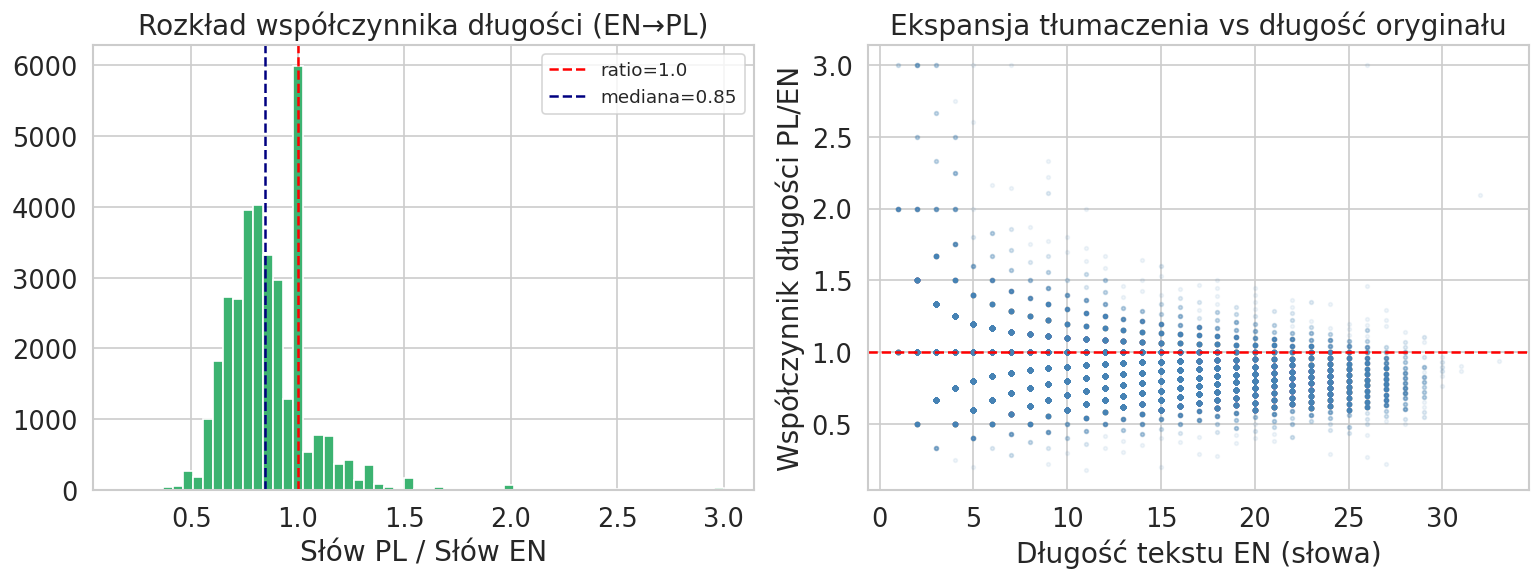

Średni współczynnik długości PL/EN: 0.87  (mediana: 0.85)
% tekstów ze współczynnikiem <0,5 (mocno ucięte): 0.4%
% tekstów ze współczynnikiem >2,0 (mocno rozdmuchane): 0.2%

=== Najbardziej ucięte tłumaczenia (najniższy współczynnik, EN >= 5 słów) ===
EN: I like [NAME]’ “I’m tired of losing, I’m not a loser”
PL: Lubię [NAME]                                                           
   ratio=0.18
---
EN: She refuses them by inhaling them [I'm sorry if that sounded bad plz no downvite]
PL: Odmawia ich wdychając.
   ratio=0.20
---
EN: You goatta be kidding me!
PL: Żartujesz!
   ratio=0.20
---

=== Najbardziej rozdmuchane tłumaczenia (najwyższy współczynnik, EN >= 5 słów) ===
EN: "LEFT TURN YIELD ON GREEN"
PL: "Left Turn YIELD ON GREEN" - to "Left Turn YIELD ON GREEN" - to "Left Turn YIELD ON GREEN" - to "Left Turn YIELD ON GREEN" - to "Left Turn YIELD ON GREEN" - to "Left Turn YIELD ON GREEN" - to "Left Turn YIELD on GREEN" - to "Left Turn YIELD on GREEN" - to "Left Turn YI
   ratio=11.8

In [11]:
go_full = pd.read_csv(Path("../data/processed/go_emotions_train.csv")).dropna(subset=["text", "text_pl"])

go_full["en_words"] = go_full["text"].str.split().str.len()
go_full["pl_words"] = go_full["text_pl"].str.split().str.len()
go_full["length_ratio"] = go_full["pl_words"] / go_full["en_words"].replace(0, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1. Length ratio distribution
go_full["length_ratio"].clip(0, 3).hist(bins=60, ax=axes[0], color="mediumseagreen", edgecolor="white")
axes[0].axvline(1.0, color="red", linestyle="--", linewidth=1.5, label="ratio=1.0")
axes[0].axvline(go_full["length_ratio"].median(), color="navy", linestyle="--", linewidth=1.5,
                label=f"mediana={go_full['length_ratio'].median():.2f}")
axes[0].set_xlabel("Słów PL / Słów EN")
axes[0].set_title("Rozkład współczynnika długości (EN→PL)")
axes[0].legend(fontsize=11)

# 2. EN length vs expansion ratio
axes[1].scatter(go_full["en_words"].clip(0, 50), go_full["length_ratio"].clip(0, 3),
                alpha=0.08, s=5, color="steelblue")
axes[1].axhline(1.0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Długość tekstu EN (słowa)")
axes[1].set_ylabel("Współczynnik długości PL/EN")
axes[1].set_title("Ekspansja tłumaczenia vs długość oryginału")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_translation_quality.pdf", bbox_inches="tight")
plt.show()

print(f"Średni współczynnik długości PL/EN: {go_full['length_ratio'].mean():.2f}  "
      f"(mediana: {go_full['length_ratio'].median():.2f})")
print(f"% tekstów ze współczynnikiem <0,5 (mocno ucięte): {(go_full['length_ratio'] < 0.5).mean() * 100:.1f}%")
print(f"% tekstów ze współczynnikiem >2,0 (mocno rozdmuchane): {(go_full['length_ratio'] > 2.0).mean() * 100:.1f}%")

# Qualitative extremes — degenerate translations at both ends of the length ratio
extreme = go_full[go_full["en_words"] >= 5]
print("\n=== Najbardziej ucięte tłumaczenia (najniższy współczynnik, EN >= 5 słów) ===")
for _, row in extreme.nsmallest(3, "length_ratio")[["text", "text_pl", "length_ratio"]].iterrows():
    print(f"EN: {row['text']}")
    print(f"PL: {row['text_pl']}")
    print(f"   ratio={row['length_ratio']:.2f}")
    print("---")
print("\n=== Najbardziej rozdmuchane tłumaczenia (najwyższy współczynnik, EN >= 5 słów) ===")
for _, row in extreme.nlargest(3, "length_ratio")[["text", "text_pl", "length_ratio"]].iterrows():
    print(f"EN: {row['text']}")
    print(f"PL: {row['text_pl']}")
    print(f"   ratio={row['length_ratio']:.2f}")
    print("---")

---
## 12. Separowalność klas — t-SNE

TF-IDF (5000 cech) → SVD(50) → t-SNE(2D). Kolor = pierwsza aktywna etykieta (`brak` = żadna).

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.decomposition import TruncatedSVD

N_SAMPLE = 2500
SEED = 42

tw_s = tw_train.sample(N_SAMPLE, random_state=SEED).copy()
go_s = go_train.sample(N_SAMPLE, random_state=SEED).copy()
ce_s = ce_train.sample(N_SAMPLE, random_state=SEED).copy()

def _dominant_emotion(row: pd.Series) -> str:
    for e in EMOTIONS:
        if row[e] == 1:
            return e
    return "brak"

tw_s["dominant"] = tw_s.apply(_dominant_emotion, axis=1)
go_s["dominant"] = go_s.apply(_dominant_emotion, axis=1)
ce_s["dominant"] = ce_s.apply(_dominant_emotion, axis=1)

# TF-IDF → TruncatedSVD(50) → t-SNE(2) — SVD keeps sparse matrix, t-SNE on 50 dims is fast
def _embed_tsne(df: pd.DataFrame, text_col: str) -> np.ndarray:
    vec = TfidfVectorizer(max_features=5000, sublinear_tf=True, min_df=2)
    X = vec.fit_transform(df[text_col].fillna(""))
    X_svd = TruncatedSVD(n_components=50, random_state=SEED).fit_transform(X)
    return TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000).fit_transform(X_svd)

print("Running t-SNE for TwitterEmo…")
tw_2d = _embed_tsne(tw_s, "clean_text")
print("Running t-SNE for GoEmotions PL…")
go_2d = _embed_tsne(go_s, "clean_text")
print("Running t-SNE for CLARIN-Emo…")
ce_2d = _embed_tsne(ce_s, "clean_text")

palette = dict(zip(EMOTIONS + ["brak"], sns.color_palette("tab10", len(EMOTIONS) + 1)))

# do \linewidth (czytelność po zmniejszeniu figury)
fig, axes = plt.subplots(2, 2, figsize=(12, 11))
panels = [
    ("TwitterEmo", tw_2d, tw_s, axes[0, 0]),
    ("GoEmotions PL", go_2d, go_s, axes[0, 1]),
    ("CLARIN-Emo", ce_2d, ce_s, axes[1, 0]),
]
handles = None
for ds_name, coords, sample, ax in panels:
    for emo in EMOTIONS + ["brak"]:
        mask = sample["dominant"].values == emo
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=[palette[emo]], label=emo, s=10, alpha=0.55)
    ax.set_title(f"{ds_name} — t-SNE (TF-IDF, n={N_SAMPLE})", fontsize=15)
    ax.set_xticks([])
    ax.set_yticks([])
    if handles is None:
        handles, labels = ax.get_legend_handles_labels()

ax_leg = axes[1, 1]
ax_leg.axis("off")
ax_leg.legend(handles, labels, loc="center", markerscale=4, fontsize=16,
              title="Dominująca emocja", title_fontsize=17, frameon=False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_tsne.pdf", bbox_inches="tight")
plt.show()

---
## 13. Warunkowe współwystępowanie emocji

P(A=1 | B=1). Macierz asymetryczna — informuje o kolejności etykiet w ClassifierChain.

In [ ]:
# Układ 2+1: dwa zbiory u góry, CLARIN-Emo pod spodem.
# — notatnik ją wywołuje, żeby kod rysujący istniał w jednym miejscu.
import sys
sys.path.insert(0, str(Path("..") / "tools"))
from gen_eda_figures import cooccurrence_figure

fig = cooccurrence_figure()
fig.savefig(FIGURES_DIR / "eda_conditional_cooccurrence.pdf", bbox_inches="tight")
plt.show()


# Top asymmetric pairs (P(A|B) >> P(B|A) → directional dependency)
records_asym = []
for a in EMOTIONS:
    for b in EMOTIONS:
        if a != b:
            p_ab = float(cond_tw.loc[a, b])
            p_ba = float(cond_tw.loc[b, a])
            records_asym.append({
                "para": f"P({a}|{b})",
                "P(A|B)": round(p_ab, 3),
                "P(B|A)": round(p_ba, 3),
                "asymetria": round(abs(p_ab - p_ba), 3),
            })
asym_df = (
    pd.DataFrame(records_asym)
    .sort_values("P(A|B)", ascending=False)
    .head(12)
    .reset_index(drop=True)
)
print("Najbardziej asymetryczne pary (TwitterEmo) — informuje o kolejności etykiet w ClassifierChain:")
display(asym_df)

---
## 14. NRC EmoLex (PL) — pokrycie i sygnał leksykalny

NRC używa dokładnie 8 emocji Plutchika, więc taksonomia zgadza się 1:1 z etykietami zadania.
Pokrycie (token/type) oraz test, czy teksty z emocją E zawierają więcej słów NRC otagowanych E.

Plik `lexicons/Polish-NRC-EmoLex.txt` — leksykon jest za formularzem na saifmohammad.com,
więc nie ma go w repozytorium.

In [ ]:
# --- Load NRC EmoLex (Polish) ---
NRC_PATH = Path("../lexicons/Polish-NRC-EmoLex.txt")
NRC_EN2PL = {
    "anger": "gniew", "anticipation": "przeczuwanie", "disgust": "wstręt",
    "fear": "strach", "joy": "radość", "sadness": "smutek",
    "surprise": "zdziwienie", "trust": "zaufanie",
}

if not NRC_PATH.exists():
    raise FileNotFoundError(
        f"NRC EmoLex (Polish) not found at {NRC_PATH}.\n"
        "Download the multilingual NRC Emotion Lexicon (short form):\n"
        "  https://saifmohammad.com/WebPages/NRC-Emotion-Lexicon.htm\n"
        "and copy OneFilePerLanguage/Polish-NRC-EmoLex.txt into lexicons/."
    )

nrc_raw = pd.read_csv(NRC_PATH, sep="\t")
_cl = {c.lower(): c for c in nrc_raw.columns}
try:
    pl_col = next(c for lc, c in _cl.items() if "polish" in lc or lc in ("pl", "translation"))
    emo_cols = {en: _cl[en] for en in NRC_EN2PL}
except (StopIteration, KeyError):
    raise KeyError(f"Unexpected NRC columns: {list(nrc_raw.columns)} — adjust column detection.")

nrc_raw[pl_col] = nrc_raw[pl_col].astype(str).str.lower()
nrc_emo_words = {
    NRC_EN2PL[en]: set(nrc_raw.loc[nrc_raw[col] == 1, pl_col]) for en, col in emo_cols.items()
}
nrc_vocab = set(nrc_raw[pl_col])
print(f"NRC EmoLex PL: {len(nrc_vocab):,} Polish words | per-emotion word counts:")
for emo in EMOTIONS:
    print(f"  {emo:>13}: {len(nrc_emo_words[emo]):>5}")


def _tok(t) -> list[str]:
    return str(t).split() if pd.notna(t) and str(t).strip() else []


def _coverage(texts: pd.Series, vocab: set) -> tuple[float, float]:
    toks = [w for tl in texts.apply(_tok) for w in tl]
    types = set(toks)
    return (
        round(sum(w in vocab for w in toks) / max(len(toks), 1) * 100, 1),
        round(len(types & vocab) / max(len(types), 1) * 100, 1),
    )


cov_rows = []
for ds, df in [("TwitterEmo", tw_train), ("GoEmotions PL", go_train), ("CLARIN-Emo", ce_train)]:
    tc, yc = _coverage(df["clean_text"], nrc_vocab)
    cov_rows.append({"dataset": ds, "token_coverage_%": tc, "type_coverage_%": yc})
print("\nNRC coverage:")
display(pd.DataFrame(cov_rows).set_index("dataset"))

# --- Per-emotion lexical signal: mean NRC-emotion word count, positive vs negative texts ---
# Positive lift (pos > neg) => the lexicon carries usable signal for that emotion.
# powiększone czcionki — czytelność po zmniejszeniu figury
fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(2, 2, hspace=0.55, wspace=0.18)
axes_nrc = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, :]),
]
for i, (ax, (ds, df)) in enumerate(zip(axes_nrc, [
    ("TwitterEmo", tw_train), ("GoEmotions PL", go_train), ("CLARIN-Emo", ce_train),
])):
    toks_all = df["clean_text"].apply(_tok)
    pos_means, neg_means = [], []
    for emo in EMOTIONS:
        ew = nrc_emo_words[emo]
        cnt = toks_all.apply(lambda ts: sum(w in ew for w in ts))
        pos_means.append(cnt[df[emo] == 1].mean())
        neg_means.append(cnt[df[emo] == 0].mean())
    x = np.arange(len(EMOTIONS))
    w = 0.4
    ax.bar(x - w / 2, pos_means, w, label="tekst z emocją", color="steelblue")
    ax.bar(x + w / 2, neg_means, w, label="bez emocji", color="lightcoral")
    ax.set_xticks(x)
    ax.set_xticklabels(EMOTIONS, rotation=40, ha="right", fontsize=14)
    ax.tick_params(axis="y", labelsize=13)
    if i in (0, 2):
        ax.set_ylabel("śr. liczba słów NRC / tekst", fontsize=14)
    ax.set_title(ds, fontsize=16, fontweight="bold")
    ax.legend(fontsize=13)
plt.savefig(FIGURES_DIR / "eda_nrc_signal.pdf", bbox_inches="tight")
plt.show()